In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("IT_Support_Ticket_Dataset_Cleaned.csv")

In [ ]:
priority_resolution = (
    df.groupby("Priority")["Resolution_Duration"]
    .mean()
    .sort_values()
)

print(priority_resolution)


Priority
Critical    0.477006
High        1.569529
Medium      3.676594
Low         6.560347
Name: Resolution_Duration, dtype: float64


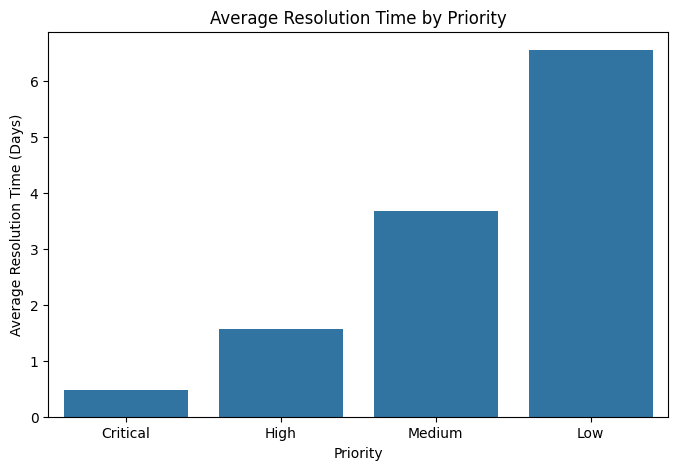

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=priority_resolution.index,
    y=priority_resolution.values
)

plt.title("Average Resolution Time by Priority")
plt.xlabel("Priority")
plt.ylabel("Average Resolution Time (Days)")

plt.show()

In [ ]:
type_resolution = (
    df.groupby("Ticket_Type")["Resolution_Duration"]
    .mean()
    .sort_values()
)

print(type_resolution)

Ticket_Type
Change      3.567797
Problem     3.591608
Request     3.682657
Incident    3.757174
Name: Resolution_Duration, dtype: float64


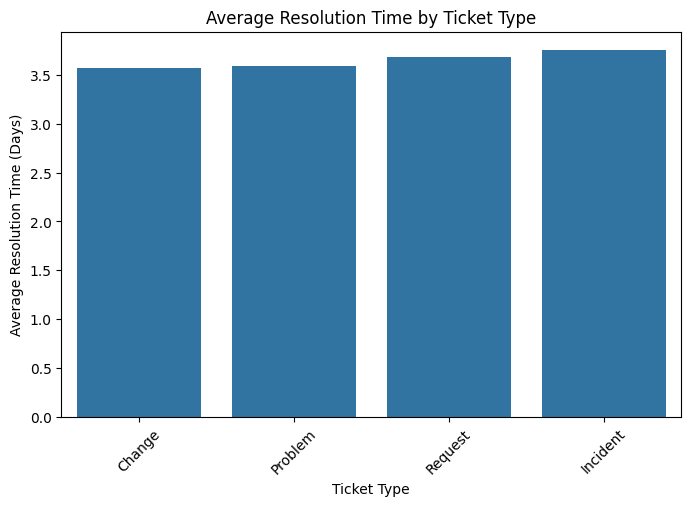

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=type_resolution.index,
    y=type_resolution.values
)

plt.title("Average Resolution Time by Ticket Type")
plt.xlabel("Ticket Type")
plt.ylabel("Average Resolution Time (Days)")
plt.xticks(rotation=45)

plt.show()

In [ ]:
country_resolution = (
    df.groupby("Country")["Resolution_Duration"]
    .mean()
    .sort_values()
)

print(country_resolution)

Country
UAE             3.426829
Japan           3.499083
France          3.528070
Australia       3.593368
USA             3.618529
Germany         3.639506
India           3.676015
UK              3.701605
Canada          3.761818
China           3.795556
Mexico          3.807895
Singapore       3.842105
Brazil          3.947846
Philippines     3.950739
South Africa    3.972727
Name: Resolution_Duration, dtype: float64


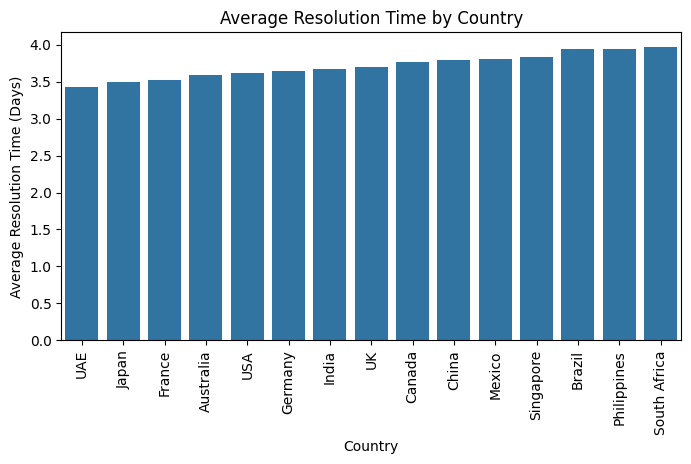

In [ ]:
plt.figure(figsize=(8,4))

sns.barplot(
    x=country_resolution.index,
    y=country_resolution.values
)

plt.title("Average Resolution Time by Country")
plt.xlabel("Country")
plt.ylabel("Average Resolution Time (Days)")
plt.xticks(rotation=90)

plt.show()

In [ ]:
country_resolution = (
    df.groupby("Country")["Resolution_Duration"]
      .mean()
      .sort_values()
      .reset_index()
)

print(country_resolution)

         Country  Resolution_Duration
0            UAE             3.426829
1          Japan             3.499083
2         France             3.528070
3      Australia             3.593368
4            USA             3.618529
5        Germany             3.639506
6          India             3.676015
7             UK             3.701605
8         Canada             3.761818
9          China             3.795556
10        Mexico             3.807895
11     Singapore             3.842105
12        Brazil             3.947846
13   Philippines             3.950739
14  South Africa             3.972727


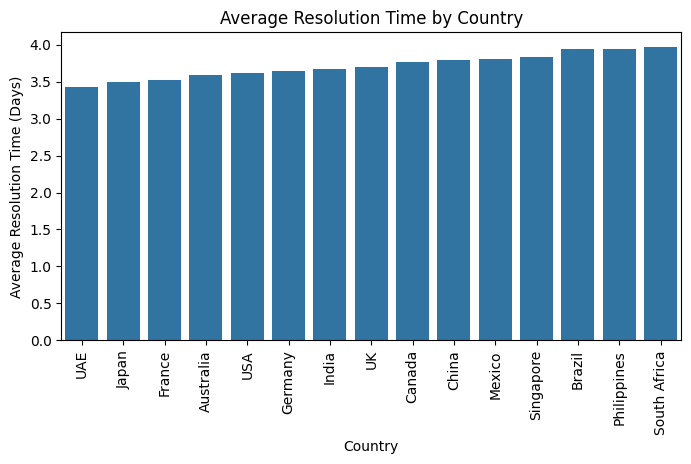

In [ ]:
plt.figure(figsize=(8,4))

sns.barplot(
    data=country_resolution,
    x="Country",
    y="Resolution_Duration"
)

plt.title("Average Resolution Time by Country")
plt.xlabel("Country")
plt.ylabel("Average Resolution Time (Days)")
plt.xticks(rotation=90)

plt.show()

In [ ]:
team_resolution = (
    df.groupby("Team")["Resolution_Duration"]
      .mean()
      .sort_values()
      .reset_index()
)

print(team_resolution)

                  Team  Resolution_Duration
0            Cloud Ops             3.643257
1        Security Team             3.645274
2             Helpdesk             3.684389
3         Network Team             3.698087
4        Database Team             3.698957
5  Infrastructure Team             3.737788
6          App Support             3.748794


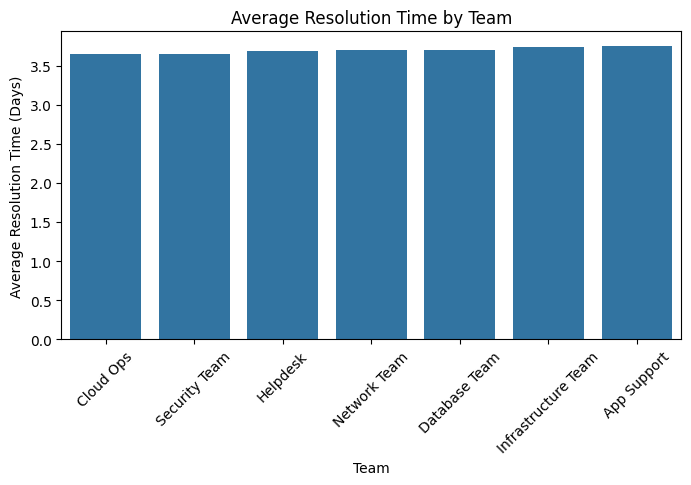

In [ ]:
plt.figure(figsize=(8,4))

sns.barplot(
    data=team_resolution,
    x="Team",
    y="Resolution_Duration"
)

plt.title("Average Resolution Time by Team")
plt.xlabel("Team")
plt.ylabel("Average Resolution Time (Days)")
plt.xticks(rotation=45)

plt.show()

In [ ]:
high_priority_unresolved = df[
    (df["Priority"].isin(["High", "Critical"])) &
    (~df["Status"].isin(["Resolved", "Closed"]))
]

print(high_priority_unresolved)

       Ticket_ID         Created_Date Resolution_Date       Status  Priority  \
10     TCK-00011  2025-12-04 01:53:00             NaN         Open      High   
16     TCK-00017  2025-07-11 04:21:00             NaN  In Progress  Critical   
25     TCK-00026  2025-11-08 17:58:00             NaN         Open      High   
59     TCK-00060  2025-01-17 11:21:00             NaN  In Progress  Critical   
110    TCK-00111  2025-04-30 05:52:00             NaN         Open  Critical   
...          ...                  ...             ...          ...       ...   
11846  TCK-11847  2025-02-06 11:02:00             NaN         Open  Critical   
11857  TCK-11858  2025-01-25 03:57:00             NaN         Open      High   
11863  TCK-11864  2025-06-02 11:40:00             NaN         Open      High   
11980  TCK-11981  2025-06-03 10:33:00             NaN  In Progress  Critical   
11982  TCK-11983  2025-11-22 08:26:00             NaN  In Progress  Critical   

      Ticket_Type           Category  C

In [ ]:
print("Number of High-Priority Unresolved Tickets:", len(high_priority_unresolved))

Number of High-Priority Unresolved Tickets: 323


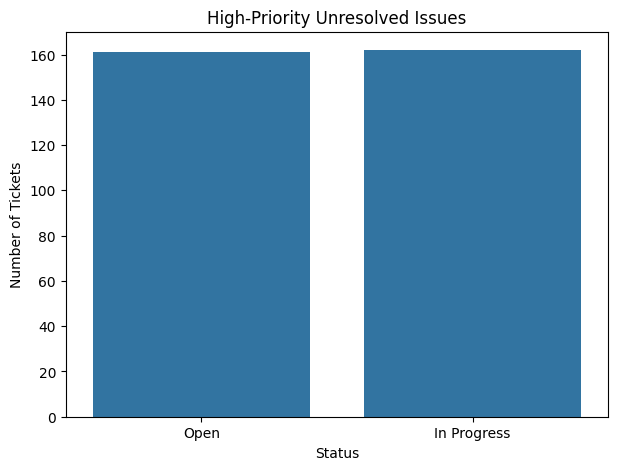

In [ ]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=high_priority_unresolved,
    x="Status"
)

plt.title("High-Priority Unresolved Issues")
plt.xlabel("Status")
plt.ylabel("Number of Tickets")

plt.show()